# Data visualization

shapely not found – CSV geometry analysis skipped. pip install shapely
Loading CSV …
  1,086,846 rows, 5372 unique plan_ids

[1/4] Single floor-plan dashboard …
Saved → /Users/emilehourmanditlefsen/Desktop/HPC/archive-3/visualizations/dashboard_10000.png


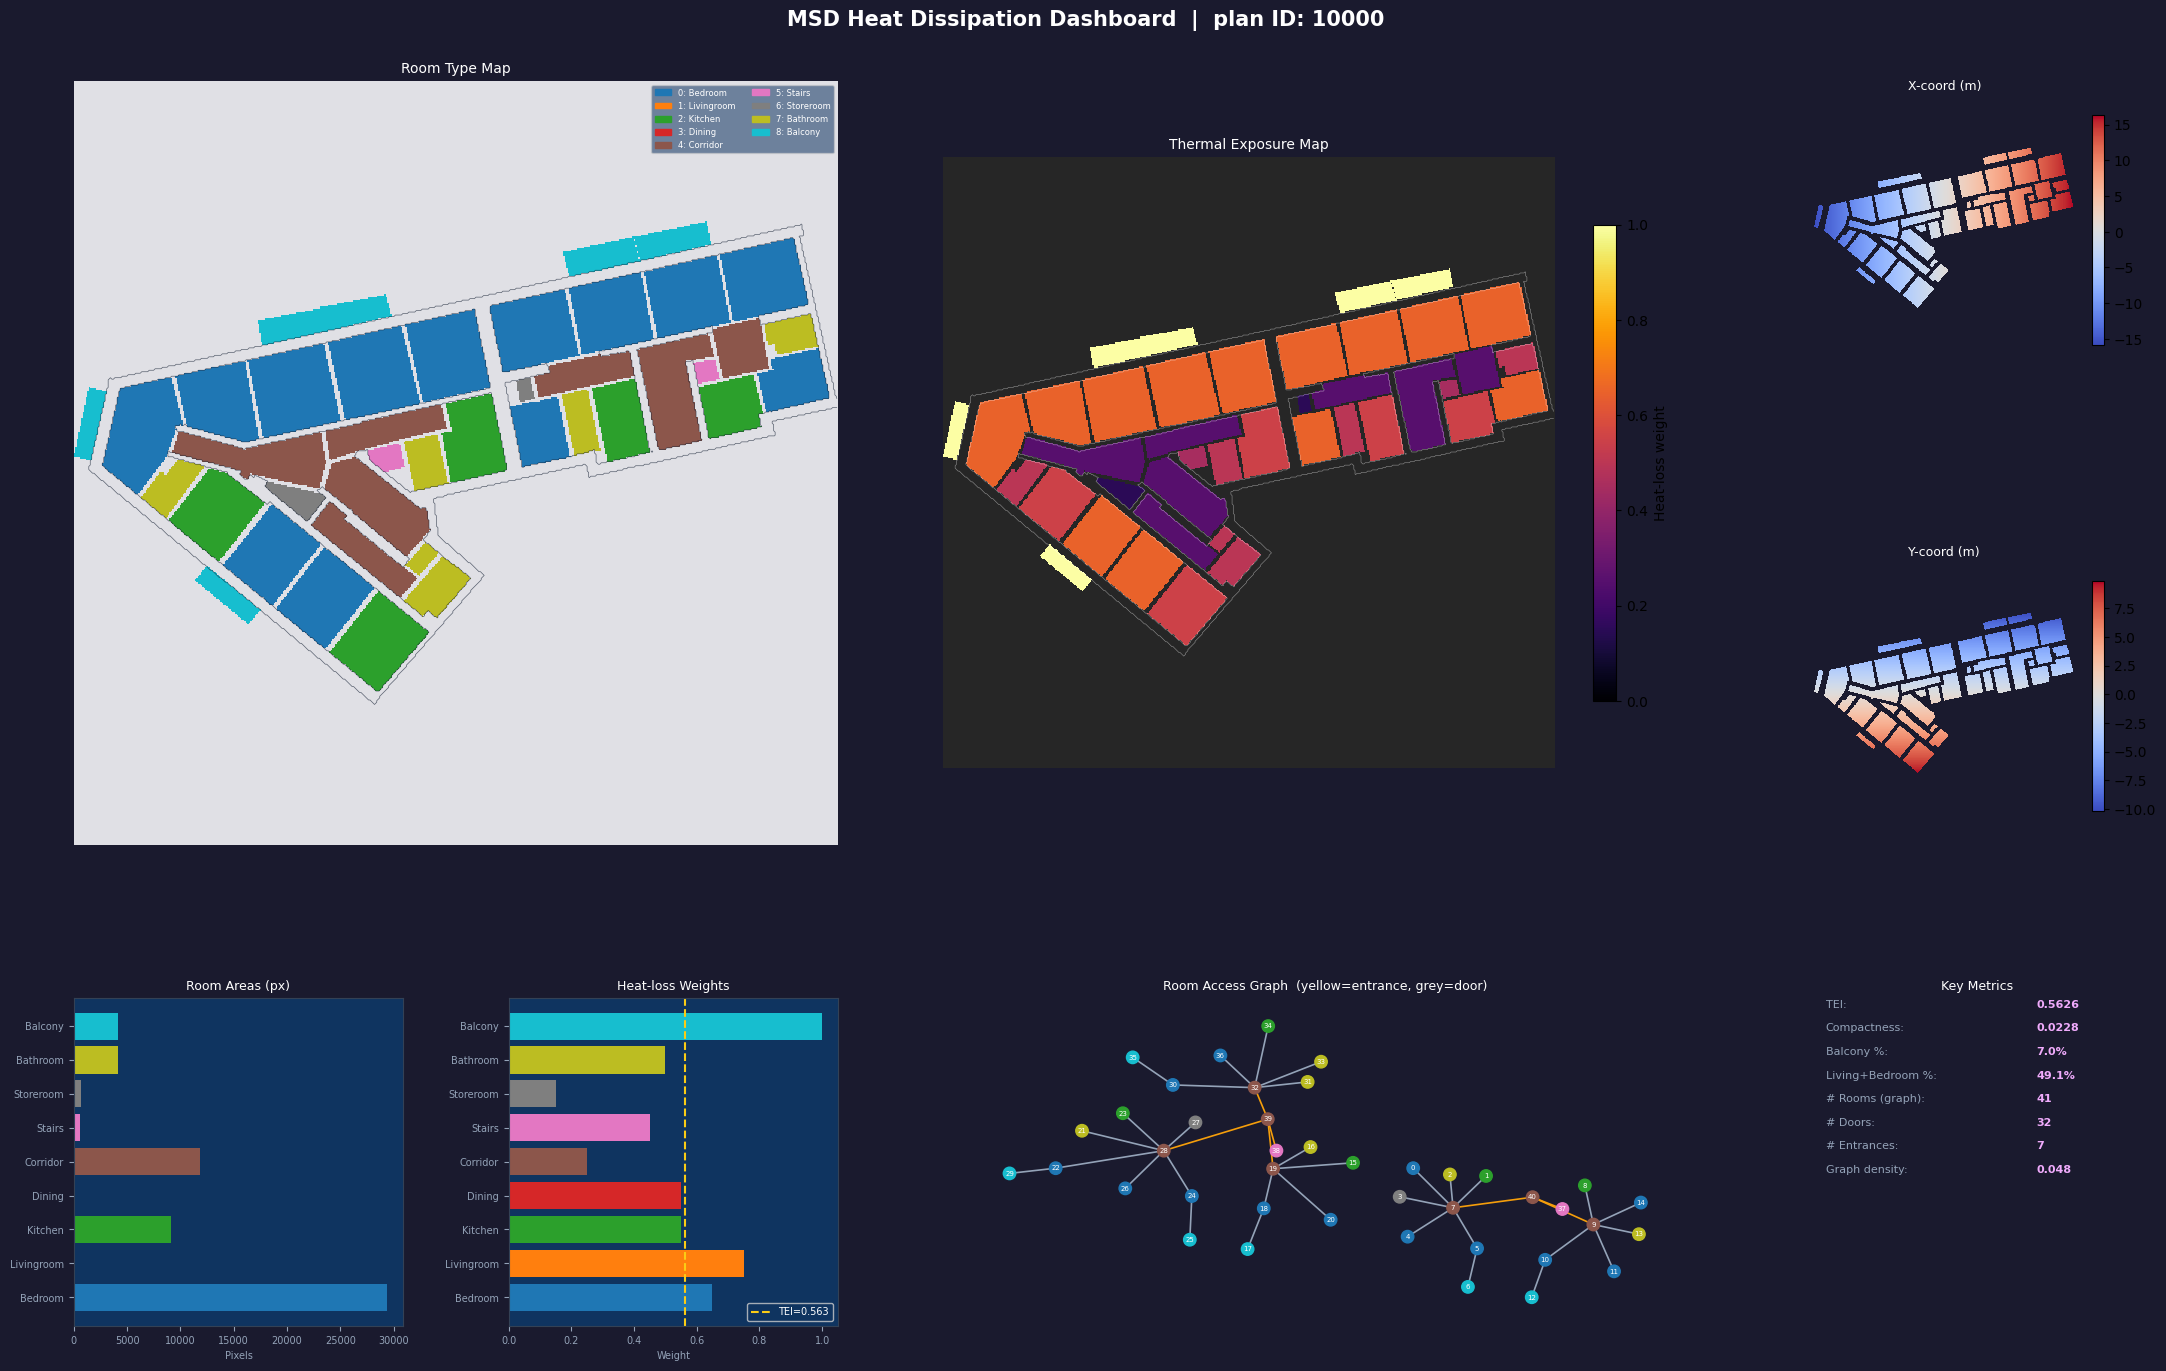


[2/4] Gallery …
Saved → /Users/emilehourmanditlefsen/Desktop/HPC/archive-3/visualizations/gallery.png


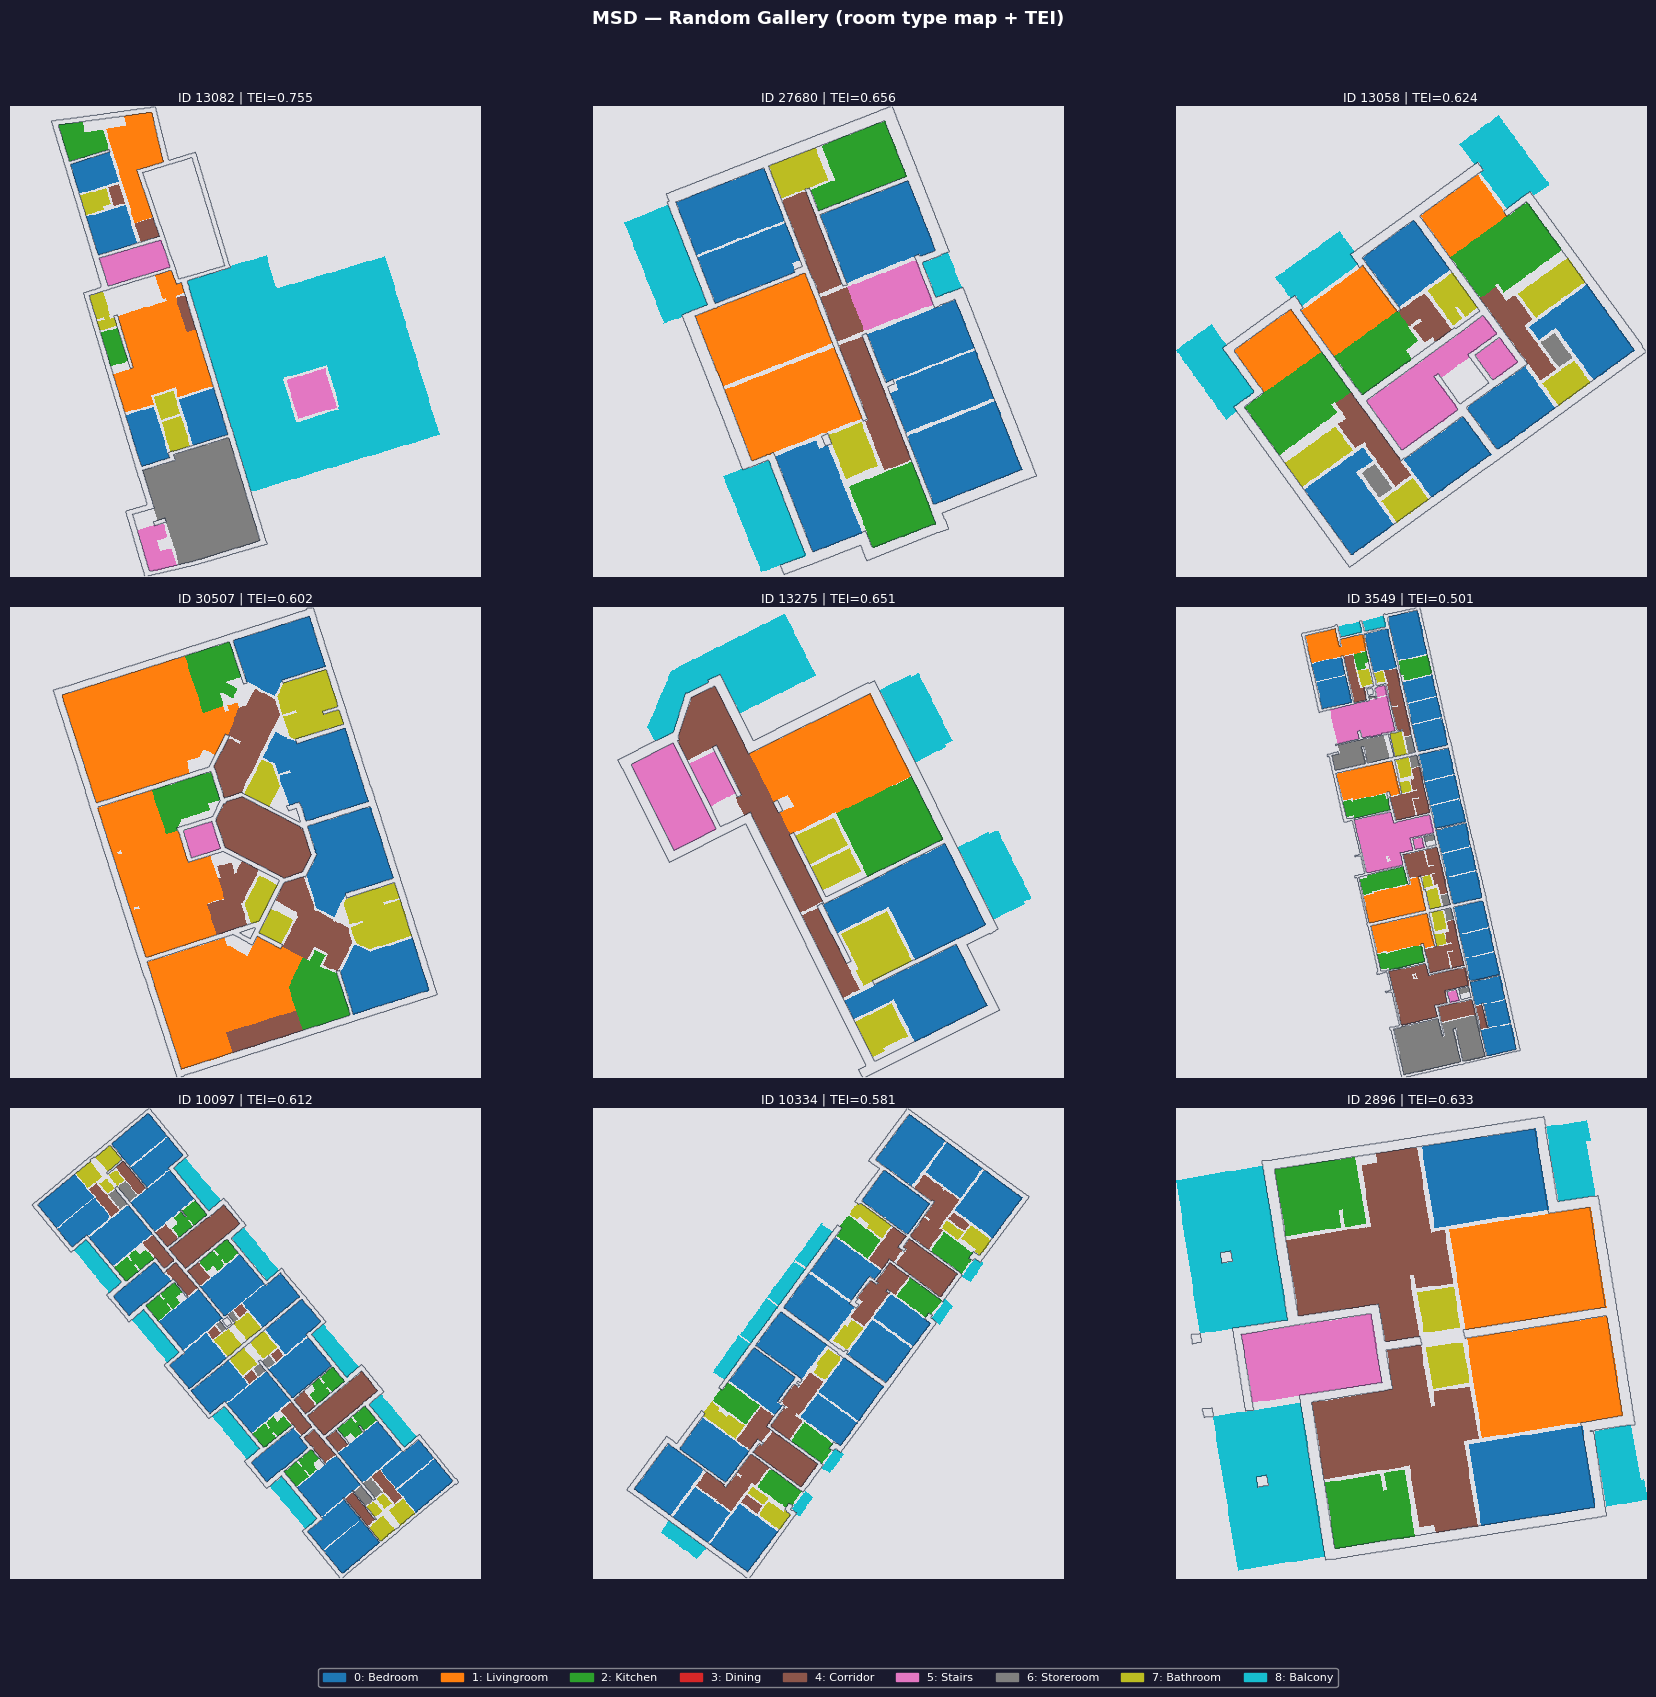


[3/4] Dataset summary …
  Computing aggregate stats over 500 floor plans …
    0/500
    200/500
    400/500
  Saved → /Users/emilehourmanditlefsen/Desktop/HPC/archive-3/visualizations/dataset_summary.png


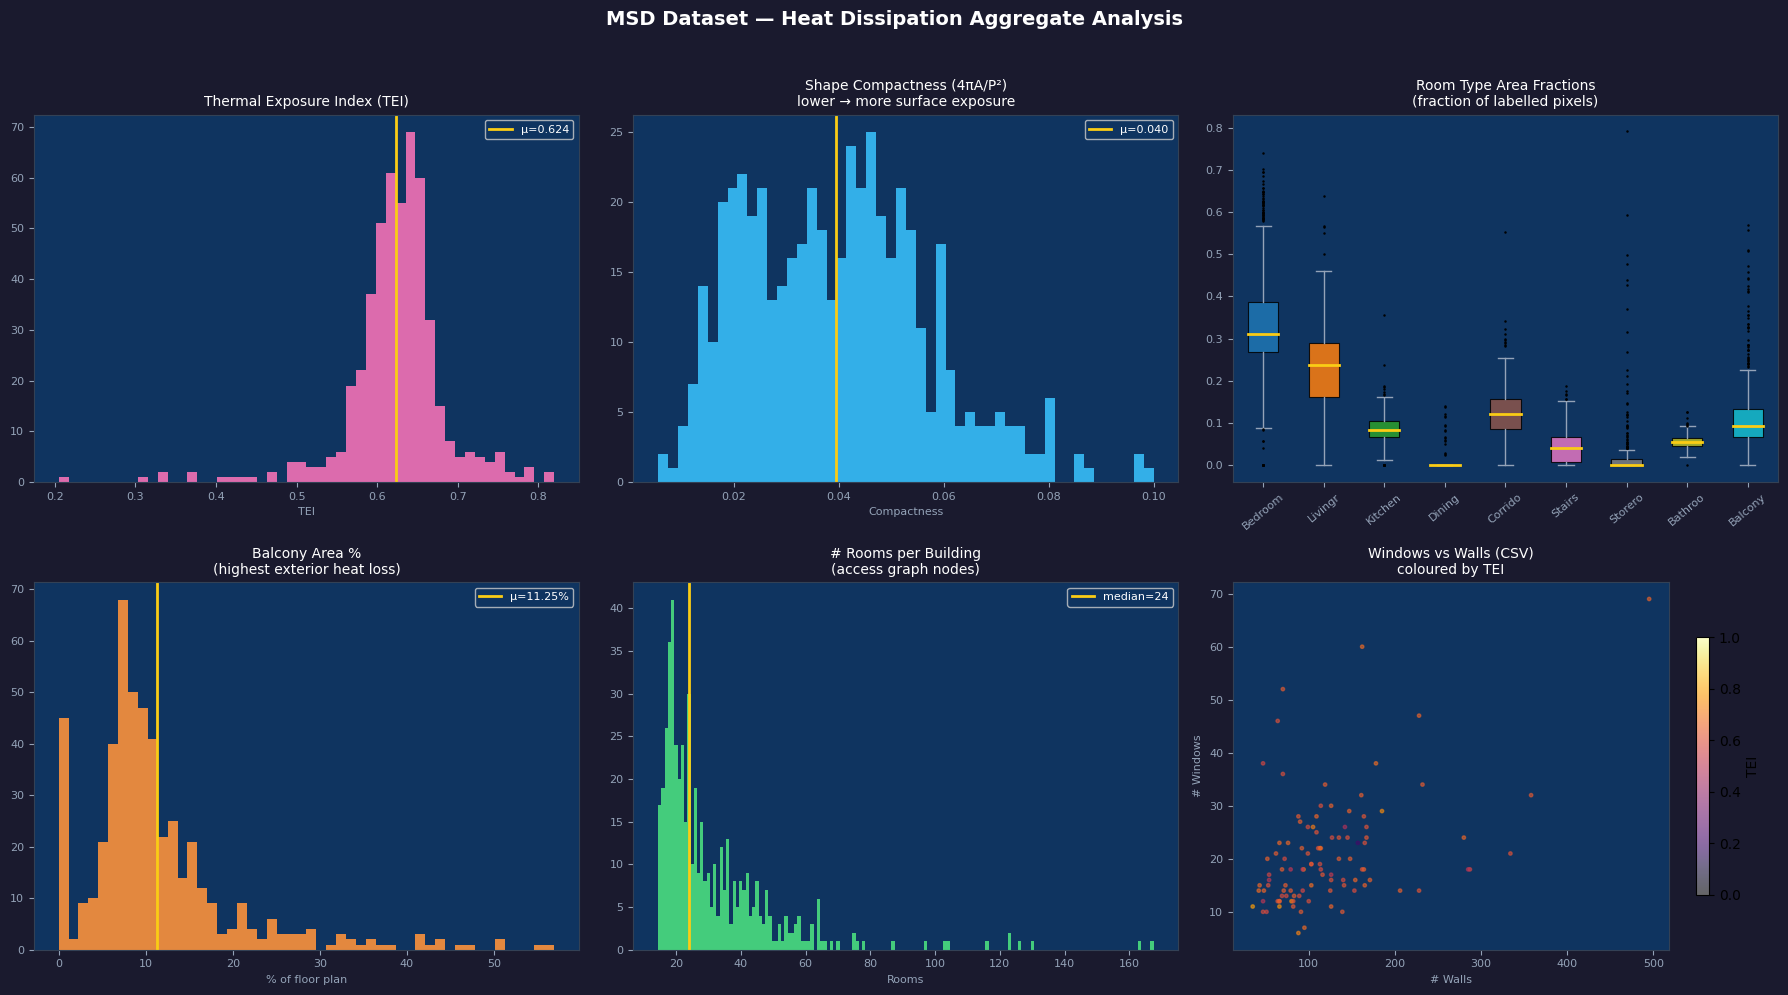


[4/4] CSV analysis …
  Saved → /Users/emilehourmanditlefsen/Desktop/HPC/archive-3/visualizations/csv_analysis.png


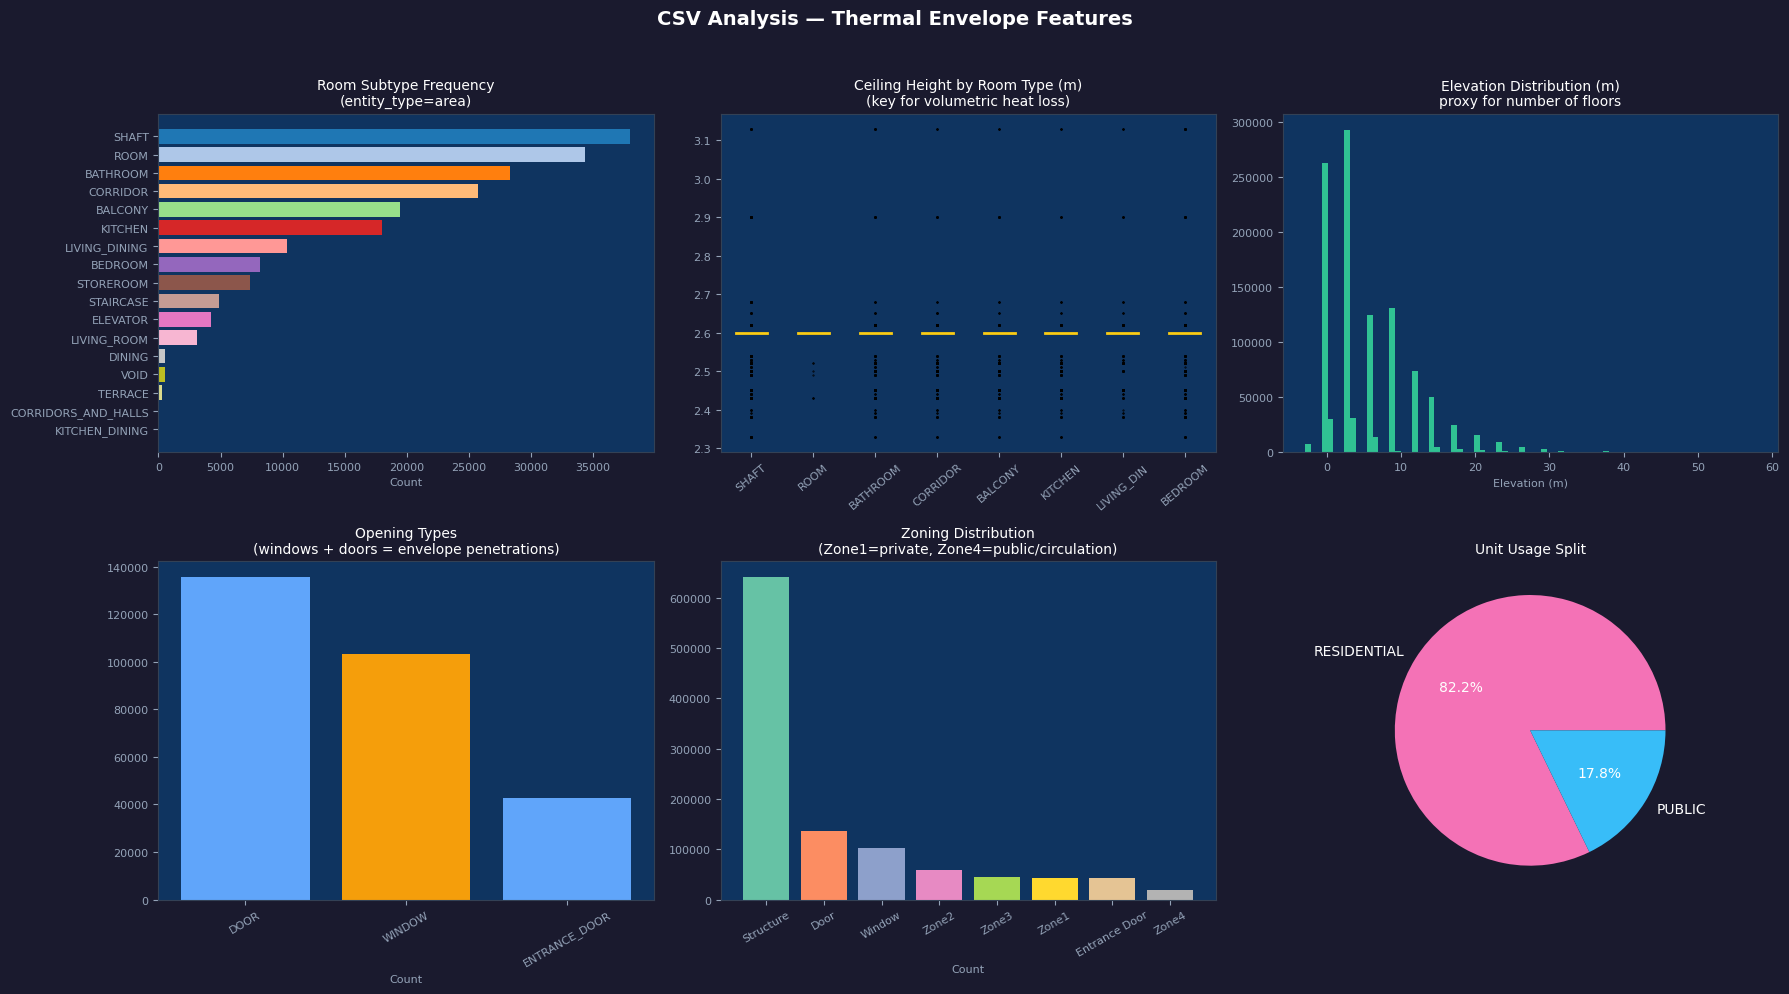


All figures saved to: /Users/emilehourmanditlefsen/Desktop/HPC/archive-3/visualizations


In [ ]:
"""
visualize_msd_heat.py  –  Heat Dissipation Analysis for Modified Swiss Dwellings v2
=====================================================================================
Usage (in Jupyter):
    %run visualize_msd_heat.py
Or plain Python:
    python visualize_msd_heat.py

Adjust BASE and the mode flags at the bottom of this file.
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from collections import defaultdict

try:
    import networkx as nx
    HAS_NX = True
except ImportError:
    HAS_NX = False
    print("networkx not found – graph panels skipped. pip install networkx")

try:
    from shapely import wkt as shapely_wkt
    from shapely.ops import unary_union
    HAS_SHAPELY = True
except ImportError:
    HAS_SHAPELY = False
    print("shapely not found – CSV geometry analysis skipped. pip install shapely")


# ─────────────────────────────────────────────────────────────────────────────
# PATHS  (edit BASE if needed)
# ─────────────────────────────────────────────────────────────────────────────
BASE  = Path("/Users/emilehourmanditlefsen/Desktop/HPC/archive-3")
TRAIN = BASE / "modified-swiss-dwellings-v2/train"
TEST  = BASE / "modified-swiss-dwellings-v2/test"
CSV   = BASE / "mds_V2_5.372k.csv"

OUT   = BASE / "visualizations"   # output folder for saved figures
OUT.mkdir(exist_ok=True)


# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────

# full_out ch0 label → name  (graph_out room_type uses same integers)
ROOM_NAMES = {
    0: "Bedroom",
    1: "Livingroom",
    2: "Kitchen",
    3: "Dining",
    4: "Corridor",
    5: "Stairs",
    6: "Storeroom",
    7: "Bathroom",
    8: "Balcony",
}

# Qualitative heat-loss weight per room (0 = no loss, 1 = max exposure)
# Rationale:
#   Balcony  – fully exterior, no insulation
#   Living   – large glazing fraction typical
#   Bedroom  – often external wall + window
#   Bathroom – forced ventilation, hot water pipes
#   Kitchen  – ventilation hood, hot water
#   Stairs   – vertical air shaft, stack effect
#   Dining   – similar to living
#   Corridor – internal buffer, low direct loss
#   Storeroom– usually interior, minimal loss
HEAT_WEIGHT = {
    0: 0.65,   # Bedroom
    1: 0.75,   # Livingroom
    2: 0.55,   # Kitchen
    3: 0.55,   # Dining
    4: 0.25,   # Corridor
    5: 0.45,   # Stairs
    6: 0.15,   # Storeroom
    7: 0.50,   # Bathroom
    8: 1.00,   # Balcony
}

# Zoning type in graph_in
ZONE_NAMES = {0: "Zone1", 1: "Zone2", 2: "Zone3", 3: "Zone4"}

# Colour map – 9 room types
ROOM_COLORS = plt.cm.get_cmap("tab10", 9)
def rc(i): return ROOM_COLORS(i)

LEGEND_PATCHES = [
    mpatches.Patch(color=rc(i), label=f"{i}: {ROOM_NAMES[i]}")
    for i in range(9)
]

# Dark theme colours
BG    = "#1a1a2e"
PANEL = "#0f3460"
LABEL = "#94a3b8"
ACC   = "#f0abfc"
YELL  = "#facc15"


# ─────────────────────────────────────────────────────────────────────────────
# I/O
# ─────────────────────────────────────────────────────────────────────────────
def get_ids(split=TRAIN):
    return sorted(p.stem for p in (split / "full_out").glob("*.npy"))

def load_full(idx, split=TRAIN):
    return np.load(split / f"full_out/{idx}.npy")   # (512,512,3) float16

def load_struct(idx, split=TRAIN):
    return np.load(split / f"struct_in/{idx}.npy")  # (512,512,3) float16

def load_graph(idx, kind="graph_out", split=TRAIN):
    p = split / f"{kind}/{idx}.pickle"
    if not p.exists(): return None
    with open(p, "rb") as f:
        return pickle.load(f)


# ─────────────────────────────────────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────────────────────────────────────
def room_areas_px(label_map):
    """Pixel counts per room class from full_out ch0."""
    return {i: int((label_map == i).sum()) for i in range(9)}

def thermal_exposure_index(areas):
    """Area-weighted heat-loss score, 0–1."""
    total = sum(areas.values()) or 1
    return sum(HEAT_WEIGHT[i] * areas[i] for i in range(9)) / total

def compactness(label_map):
    """4πA/P²  – circle=1, thin slab→0.  Lower = more surface area per volume."""
    from scipy.ndimage import binary_erosion
    occupied = (label_map >= 0) & (label_map <= 8)
    A = occupied.sum()
    if A == 0: return np.nan
    eroded = binary_erosion(occupied)
    P = (occupied & ~eroded).sum()
    if P == 0: return np.nan
    return float(4 * np.pi * A / P**2)

def graph_metrics(g):
    if g is None or not HAS_NX: return {}
    try:
        return {
            "n_rooms":   g.number_of_nodes(),
            "n_edges":   g.number_of_edges(),
            "density":   nx.density(g),
            "n_doors":   sum(1 for _,_,d in g.edges(data=True) if d.get("connectivity")=="door"),
            "n_entrance":sum(1 for _,_,d in g.edges(data=True) if d.get("connectivity")=="entrance"),
        }
    except Exception:
        return {}

def csv_metrics_for_plan(df_plan):
    """Aggregate heat-relevant stats from CSV rows for one plan_id."""
    out = {}
    areas  = df_plan[df_plan.entity_type == "area"]
    opens  = df_plan[df_plan.entity_type == "opening"]
    seps   = df_plan[df_plan.entity_type == "separator"]

    out["n_windows"]   = int((opens.entity_subtype == "WINDOW").sum())
    out["n_doors"]     = int((opens.entity_subtype == "DOOR").sum())
    out["n_ent_doors"] = int((opens.entity_subtype == "ENTRANCE_DOOR").sum())
    out["n_walls"]     = int((seps.entity_subtype == "WALL").sum())
    out["n_columns"]   = int((seps.entity_subtype == "COLUMN").sum())

    if HAS_SHAPELY:
        try:
            geoms = areas["geom"].dropna().apply(shapely_wkt.loads)
            out["total_area_m2"]  = float(geoms.apply(lambda g: g.area).sum())
            balcony = areas[areas.entity_subtype == "BALCONY"]["geom"].dropna().apply(shapely_wkt.loads)
            out["balcony_area_m2"] = float(balcony.apply(lambda g: g.area).sum()) if len(balcony) else 0.0
            win_geoms = opens[opens.entity_subtype == "WINDOW"]["geom"].dropna().apply(shapely_wkt.loads)
            out["window_area_m2"] = float(win_geoms.apply(lambda g: g.area).sum()) if len(win_geoms) else 0.0
        except Exception:
            pass

    h = df_plan["height"].dropna()
    out["mean_height_m"] = float(h.mean()) if len(h) else np.nan
    out["max_height_m"]  = float(h.max())  if len(h) else np.nan

    e = df_plan["elevation"].dropna()
    out["n_floors"] = int(round((e.max() - e.min()) / 2.6)) + 1 if len(e) > 1 else 1

    return out


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1: Single floor-plan dashboard
# ─────────────────────────────────────────────────────────────────────────────
def plot_dashboard(idx, split=TRAIN, df_csv=None, save=True):
    full   = load_full(idx, split)
    struct = load_struct(idx, split)
    g_out  = load_graph(idx, "graph_out", split)

    label_raw = full[..., 0].astype(np.float32)
    x_real    = full[..., 1]
    y_real    = full[..., 2]
    struct_bin = struct[..., 0]  # 0 or 255

    # Valid room pixels: integer 0–8
    room_mask = np.isin(label_raw.astype(int), list(range(9))) & (label_raw >= 0) & (label_raw <= 8)
    label = np.where(room_mask, label_raw.astype(int), -1)

    areas   = room_areas_px(label)
    tei     = thermal_exposure_index(areas)
    gm      = graph_metrics(g_out)

    # Build RGB room map
    H, W = label.shape
    rgb = np.ones((H, W, 4))
    rgb[..., :3] = [0.88, 0.88, 0.90]  # light grey exterior default
    for i in range(9):
        m = (label == i)
        rgb[m, :3] = rc(i)[:3]
        rgb[m,  3] = 1.0

    # Build thermal map — only on valid room pixels
    heat_px = np.zeros((H, W), dtype=np.float32)
    for i in range(9):
        heat_px[label == i] = HEAT_WEIGHT[i]
    heat_px[label == -1] = np.nan  # exterior → transparent

    fig = plt.figure(figsize=(22, 14), facecolor=BG)
    fig.suptitle(f"MSD Heat Dissipation Dashboard  |  plan ID: {idx}",
                 color="white", fontsize=15, fontweight="bold", y=0.99)
    gs = GridSpec(3, 5, figure=fig, hspace=0.42, wspace=0.32,
                  left=0.04, right=0.98, top=0.95, bottom=0.05)

    def new_ax(*args):
        ax = fig.add_subplot(*args)
        ax.set_facecolor(PANEL)
        return ax

    # ── A: Room map ───────────────────────────────────────────────────────────
    axA = new_ax(gs[0:2, 0:2])
    axA.imshow(rgb, origin="upper", interpolation="nearest")
    axA.contour(struct_bin, levels=[127], colors=["#1e293b"], linewidths=0.5, alpha=0.7)
    axA.set_title("Room Type Map", color="white", fontsize=10)
    axA.legend(handles=LEGEND_PATCHES, loc="upper right",
               fontsize=6, framealpha=0.55, ncol=2,
               facecolor=PANEL, labelcolor="white")
    axA.axis("off")

    # ── B: Thermal exposure ───────────────────────────────────────────────────
    axB = new_ax(gs[0:2, 2:4])
    # grey exterior background first
    axB.imshow(np.ones((H, W, 3)) * 0.15, origin="upper")
    im = axB.imshow(heat_px, cmap="inferno", vmin=0, vmax=1,
                    origin="upper", interpolation="nearest")
    axB.contour(struct_bin, levels=[127], colors="white", linewidths=0.4, alpha=0.5)
    plt.colorbar(im, ax=axB, shrink=0.6, label="Heat-loss weight")
    axB.set_title("Thermal Exposure Map", color="white", fontsize=10)
    axB.axis("off")

    # ── C/D: Coordinate grids ─────────────────────────────────────────────────
    axC = new_ax(gs[0, 4])
    # mask coords to room pixels only
    x_show = np.where(room_mask, x_real, np.nan)
    im2 = axC.imshow(x_show, cmap="coolwarm", origin="upper")
    plt.colorbar(im2, ax=axC, shrink=0.7)
    axC.set_title("X-coord (m)", color="white", fontsize=9)
    axC.axis("off")

    axD = new_ax(gs[1, 4])
    y_show = np.where(room_mask, y_real, np.nan)
    im3 = axD.imshow(y_show, cmap="coolwarm", origin="upper")
    plt.colorbar(im3, ax=axD, shrink=0.7)
    axD.set_title("Y-coord (m)", color="white", fontsize=9)
    axD.axis("off")

    # ── E: Room area bars ─────────────────────────────────────────────────────
    axE = new_ax(gs[2, 0])
    labels_e = [ROOM_NAMES[i] for i in range(9)]
    vals_e   = [areas[i] for i in range(9)]
    cols_e   = [rc(i) for i in range(9)]
    axE.barh(labels_e, vals_e, color=cols_e)
    axE.set_xlabel("Pixels", color=LABEL, fontsize=7)
    axE.set_title("Room Areas (px)", color="white", fontsize=9)
    axE.tick_params(colors=LABEL, labelsize=7)
    for sp in axE.spines.values(): sp.set_color("#334155")

    # ── F: Heat weights ───────────────────────────────────────────────────────
    axF = new_ax(gs[2, 1])
    hw_vals = [HEAT_WEIGHT[i] for i in range(9)]
    axF.barh(labels_e, hw_vals, color=cols_e)
    axF.axvline(tei, color=YELL, lw=1.5, linestyle="--", label=f"TEI={tei:.3f}")
    axF.set_xlabel("Weight", color=LABEL, fontsize=7)
    axF.set_title("Heat-loss Weights", color="white", fontsize=9)
    axF.legend(fontsize=7, facecolor=PANEL, labelcolor="white")
    axF.tick_params(colors=LABEL, labelsize=7)
    for sp in axF.spines.values(): sp.set_color("#334155")

    # ── G: Access graph ───────────────────────────────────────────────────────
    axG = new_ax(gs[2, 2:4])
    axG.axis("off")
    if g_out is not None and HAS_NX:
        try:
            pos = {}
            for n, d in g_out.nodes(data=True):
                c = d.get("centroid")
                if c is not None:
                    try: pos[n] = (float(c[0]), float(c[1]))
                    except: pass
            if len(pos) < g_out.number_of_nodes():
                pos = nx.spring_layout(g_out, seed=42)
            node_c = [rc(d.get("room_type", 0)) for _, d in g_out.nodes(data=True)]
            edge_colors = ["#f59e0b" if d.get("connectivity") == "entrance" else "#94a3b8"
                           for _,_,d in g_out.edges(data=True)]
            nx.draw_networkx(g_out, pos=pos, ax=axG,
                             node_color=node_c, node_size=80,
                             font_size=5, font_color="white",
                             edge_color=edge_colors, width=1.2,
                             with_labels=True, arrows=False)
            axG.set_title("Room Access Graph  (yellow=entrance, grey=door)",
                          color="white", fontsize=9)
        except Exception as e:
            axG.text(0.5, 0.5, f"Graph error: {e}", color="orange",
                     ha="center", va="center", transform=axG.transAxes)

    # ── H: Metrics ────────────────────────────────────────────────────────────
    axH = new_ax(gs[2, 4])
    axH.axis("off")
    axH.set_title("Key Metrics", color="white", fontsize=9)

    comp = compactness(label)
    total_px = sum(areas.values()) or 1
    metrics = {
        "TEI":               f"{tei:.4f}",
        "Compactness":       f"{comp:.4f}" if not np.isnan(comp) else "N/A",
        "Balcony %":         f"{100*areas[8]/total_px:.1f}%",
        "Living+Bedroom %":  f"{100*(areas[0]+areas[1])/total_px:.1f}%",
        "# Rooms (graph)":   str(gm.get("n_rooms","–")),
        "# Doors":           str(gm.get("n_doors","–")),
        "# Entrances":       str(gm.get("n_entrance","–")),
        "Graph density":     f"{gm.get('density',0):.3f}",
    }
    if df_csv is not None:
        df_plan = df_csv[df_csv.plan_id == int(idx)]
        if len(df_plan):
            cm = csv_metrics_for_plan(df_plan)
            metrics["Windows (CSV)"]     = str(cm.get("n_windows","–"))
            metrics["Walls (CSV)"]       = str(cm.get("n_walls","–"))
            metrics["Mean height (m)"]   = f"{cm.get('mean_height_m',np.nan):.2f}"
            metrics["Est. floors"]       = str(cm.get("n_floors","–"))
            if "total_area_m2"   in cm: metrics["Total area (m²)"]   = f"{cm['total_area_m2']:.1f}"
            if "window_area_m2"  in cm: metrics["Window area (m²)"]  = f"{cm['window_area_m2']:.2f}"
            if "balcony_area_m2" in cm: metrics["Balcony area (m²)"] = f"{cm['balcony_area_m2']:.2f}"

    y = 0.97
    for k, v in metrics.items():
        axH.text(0.04, y, f"{k}:", color=LABEL, fontsize=8, transform=axH.transAxes)
        axH.text(0.68, y, v, color=ACC, fontsize=8, fontweight="bold", transform=axH.transAxes)
        y -= 0.072

    if save:
        path = OUT / f"dashboard_{idx}.png"
        plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=BG)
        print(f"Saved → {path}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2: Gallery of N random floor plans
# ─────────────────────────────────────────────────────────────────────────────
def plot_gallery(n=9, split=TRAIN, seed=42, save=True):
    np.random.seed(seed)
    ids = get_ids(split)
    chosen = np.random.choice(ids, size=min(n, len(ids)), replace=False)

    cols = 3
    rows = int(np.ceil(len(chosen) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*5.5), facecolor=BG)
    fig.suptitle("MSD — Random Gallery (room type map + TEI)", color="white",
                 fontsize=13, fontweight="bold", y=1.0)
    axes = np.array(axes).ravel()

    for ax, idx in zip(axes, chosen):
        full   = load_full(idx, split)
        struct = load_struct(idx, split)

        label      = full[..., 0]          # float, values 0.0–8.0 (room) or outside
        struct_bin = struct[..., 0]        # 0 or 255

        # Build RGBA: start white, paint rooms by class
        H, W = label.shape
        rgb = np.ones((H, W, 4))           # white background

        for i in range(9):
            mask = (label == i)
            color = rc(i)
            rgb[mask, :3] = color[:3]
            rgb[mask,  3] = 1.0

        # Pixels that are 0 in struct AND not a room label → background/exterior → light grey
        room_mask = np.isin(label, list(range(9)))
        exterior  = (~room_mask)
        rgb[exterior] = [0.88, 0.88, 0.90, 1.0]

        ax.set_facecolor("white")
        ax.imshow(rgb, origin="upper", interpolation="nearest")

        # Thin wall contour on top
        ax.contour(struct_bin, levels=[127], colors=["#1e293b"], linewidths=0.6, alpha=0.8)

        areas = room_areas_px(label)
        tei   = thermal_exposure_index(areas)
        ax.set_title(f"ID {idx} | TEI={tei:.3f}", color="white", fontsize=9, pad=4)
        ax.axis("off")

    for ax in axes[len(chosen):]:
        ax.set_visible(False)

    fig.legend(handles=LEGEND_PATCHES, loc="lower center", ncol=9,
               fontsize=8, facecolor=BG, labelcolor="white",
               bbox_to_anchor=(0.5, -0.02), framealpha=0.6)
    plt.tight_layout(rect=[0, 0.04, 1, 0.98])

    if save:
        path = OUT / "gallery.png"
        plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=BG)
        print(f"Saved → {path}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3: Dataset-wide aggregate stats
# ─────────────────────────────────────────────────────────────────────────────
def plot_dataset_summary(max_n=1000, split=TRAIN, df_csv=None, seed=42, save=True):
    np.random.seed(seed)
    ids = get_ids(split)
    ids = list(np.random.choice(ids, size=min(max_n, len(ids)), replace=False))
    print(f"  Computing aggregate stats over {len(ids)} floor plans …")

    tei_list, compact_list, balcony_pct, n_rooms_list = [], [], [], []
    area_frac = defaultdict(list)
    height_list, window_cnt, wall_cnt, floor_cnt = [], [], [], []

    for k, idx in enumerate(ids):
        if k % 200 == 0: print(f"    {k}/{len(ids)}")
        try:
            full  = load_full(idx, split)
            label = full[..., 0]
            areas = room_areas_px(label)
            total = sum(areas.values()) or 1

            tei_list.append(thermal_exposure_index(areas))
            compact_list.append(compactness(label))
            balcony_pct.append(100 * areas[8] / total)
            for i in range(9):
                area_frac[i].append(areas[i] / total)

            g = load_graph(idx, "graph_out", split)
            if g is not None and HAS_NX:
                n_rooms_list.append(g.number_of_nodes())
        except Exception:
            continue

        if df_csv is not None:
            df_plan = df_csv[df_csv.plan_id == int(idx)]
            if len(df_plan):
                cm = csv_metrics_for_plan(df_plan)
                height_list.append(cm.get("mean_height_m", np.nan))
                window_cnt.append(cm.get("n_windows", 0))
                wall_cnt.append(cm.get("n_walls", 0))
                floor_cnt.append(cm.get("n_floors", 1))

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=BG)
    fig.suptitle("MSD Dataset — Heat Dissipation Aggregate Analysis",
                 color="white", fontsize=14, fontweight="bold", y=0.99)

    def style(ax, title, xlabel=""):
        ax.set_facecolor(PANEL)
        ax.set_title(title, color="white", fontsize=10, pad=6)
        ax.set_xlabel(xlabel, color=LABEL, fontsize=8)
        ax.tick_params(colors=LABEL, labelsize=8)
        for sp in ax.spines.values(): sp.set_color("#334155")

    # 1. TEI distribution
    ax = axes[0, 0]
    ax.hist(tei_list, bins=50, color="#f472b6", edgecolor="none", alpha=0.9)
    ax.axvline(np.mean(tei_list), color=YELL, lw=2, label=f"μ={np.mean(tei_list):.3f}")
    ax.legend(fontsize=8, facecolor=PANEL, labelcolor="white")
    style(ax, "Thermal Exposure Index (TEI)", "TEI")

    # 2. Shape compactness
    ax = axes[0, 1]
    vals = [v for v in compact_list if not np.isnan(v)]
    ax.hist(vals, bins=50, color="#38bdf8", edgecolor="none", alpha=0.9)
    ax.axvline(np.mean(vals), color=YELL, lw=2, label=f"μ={np.mean(vals):.3f}")
    ax.legend(fontsize=8, facecolor=PANEL, labelcolor="white")
    style(ax, "Shape Compactness (4πA/P²)\nlower → more surface exposure", "Compactness")

    # 3. Room type area fraction box plot
    ax = axes[0, 2]
    box_data   = [area_frac[i] for i in range(9)]
    box_labels = [ROOM_NAMES[i][:7] for i in range(9)]
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                    medianprops=dict(color=YELL, lw=2),
                    flierprops=dict(marker=".", color=LABEL, markersize=1.5),
                    whiskerprops=dict(color=LABEL),
                    capprops=dict(color=LABEL),
                    boxprops=dict(linewidth=0.8))
    for patch, i in zip(bp["boxes"], range(9)):
        patch.set_facecolor(rc(i)); patch.set_alpha(0.85)
    ax.tick_params(axis="x", rotation=40, labelsize=7)
    style(ax, "Room Type Area Fractions\n(fraction of labelled pixels)", "")

    # 4. Balcony %
    ax = axes[1, 0]
    ax.hist(balcony_pct, bins=50, color="#fb923c", edgecolor="none", alpha=0.9)
    ax.axvline(np.mean(balcony_pct), color=YELL, lw=2,
               label=f"μ={np.mean(balcony_pct):.2f}%")
    ax.legend(fontsize=8, facecolor=PANEL, labelcolor="white")
    style(ax, "Balcony Area %\n(highest exterior heat loss)", "% of floor plan")

    # 5. Access graph size (# rooms)
    ax = axes[1, 1]
    if n_rooms_list:
        ax.hist(n_rooms_list, bins=range(min(n_rooms_list), max(n_rooms_list)+2),
                color="#4ade80", edgecolor="none", alpha=0.9, align="left")
        ax.axvline(np.median(n_rooms_list), color=YELL, lw=2,
                   label=f"median={np.median(n_rooms_list):.0f}")
        ax.legend(fontsize=8, facecolor=PANEL, labelcolor="white")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    style(ax, "# Rooms per Building\n(access graph nodes)", "Rooms")

    # 6. CSV-derived: window count vs wall count scatter, or floor distribution
    ax = axes[1, 2]
    if window_cnt and wall_cnt:
        sc = ax.scatter(wall_cnt, window_cnt, c=tei_list[:len(window_cnt)],
                        cmap="inferno", s=6, alpha=0.6, vmin=0, vmax=1)
        plt.colorbar(sc, ax=ax, shrink=0.7, label="TEI")
        style(ax, "Windows vs Walls (CSV)\ncoloured by TEI", "# Walls")
        ax.set_ylabel("# Windows", color=LABEL, fontsize=8)
    elif floor_cnt:
        ax.hist(floor_cnt, bins=range(1, max(floor_cnt)+2), color="#a78bfa",
                edgecolor="none", alpha=0.9, align="left")
        style(ax, "Estimated # Floors\n(from CSV elevation range)", "Floors")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save:
        path = OUT / "dataset_summary.png"
        plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=BG)
        print(f"  Saved → {path}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 4: CSV deep-dive — thermal envelope from real geometry
# ─────────────────────────────────────────────────────────────────────────────
def plot_csv_analysis(df_csv, save=True):
    """Analyse the CSV globally for heat-dissipation relevant features."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=BG)
    fig.suptitle("CSV Analysis — Thermal Envelope Features",
                 color="white", fontsize=14, fontweight="bold", y=0.99)

    def style(ax, title, xlabel=""):
        ax.set_facecolor(PANEL)
        ax.set_title(title, color="white", fontsize=10, pad=6)
        ax.set_xlabel(xlabel, color=LABEL, fontsize=8)
        ax.tick_params(colors=LABEL, labelsize=8)
        for sp in ax.spines.values(): sp.set_color("#334155")

    areas = df_csv[df_csv.entity_type == "area"]
    opens = df_csv[df_csv.entity_type == "opening"]
    seps  = df_csv[df_csv.entity_type == "separator"]

    # 1. Room subtype frequency (areas only)
    ax = axes[0, 0]
    vc = areas["entity_subtype"].value_counts()
    colors_vc = plt.cm.tab20(np.linspace(0, 1, len(vc)))
    ax.barh(vc.index[::-1], vc.values[::-1], color=colors_vc[::-1])
    style(ax, "Room Subtype Frequency\n(entity_type=area)", "Count")

    # 2. Height distribution by entity subtype (top 8)
    ax = axes[0, 1]
    top_subtypes = areas["entity_subtype"].value_counts().head(8).index
    box_data2  = [areas[areas.entity_subtype == s]["height"].dropna().values for s in top_subtypes]
    bp2 = ax.boxplot(box_data2, labels=[s[:10] for s in top_subtypes],
                     patch_artist=True,
                     medianprops=dict(color=YELL, lw=2),
                     flierprops=dict(marker=".", color=LABEL, markersize=1))
    for patch, col in zip(bp2["boxes"], plt.cm.tab10(np.linspace(0,1,8))):
        patch.set_facecolor(col); patch.set_alpha(0.85)
    ax.tick_params(axis="x", rotation=40, labelsize=7)
    style(ax, "Ceiling Height by Room Type (m)\n(key for volumetric heat loss)", "")

    # 3. Elevation distribution (floor levels)
    ax = axes[0, 2]
    elev = df_csv["elevation"].dropna()
    ax.hist(elev, bins=80, color="#34d399", edgecolor="none", alpha=0.9)
    style(ax, "Elevation Distribution (m)\nproxy for number of floors", "Elevation (m)")

    # 4. Opening type breakdown
    ax = axes[1, 0]
    vc2 = opens["entity_subtype"].value_counts()
    ax.bar(vc2.index, vc2.values,
           color=["#f59e0b" if "WINDOW" in s else "#60a5fa" for s in vc2.index])
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    style(ax, "Opening Types\n(windows + doors = envelope penetrations)", "Count")

    # 5. Zoning breakdown
    ax = axes[1, 1]
    vc3 = df_csv["zoning"].value_counts()
    colors_z = plt.cm.Set2(np.linspace(0, 1, len(vc3)))
    ax.bar(vc3.index, vc3.values, color=colors_z)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    style(ax, "Zoning Distribution\n(Zone1=private, Zone4=public/circulation)", "Count")

    # 6. Unit usage
    ax = axes[1, 2]
    vc4 = df_csv["unit_usage"].value_counts()
    ax.pie(vc4.values, labels=vc4.index, autopct="%1.1f%%",
           colors=["#f472b6", "#38bdf8"],
           textprops={"color": "white", "fontsize": 10})
    ax.set_facecolor(PANEL)
    ax.set_title("Unit Usage Split", color="white", fontsize=10, pad=6)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save:
        path = OUT / "csv_analysis.png"
        plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=BG)
        print(f"  Saved → {path}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# RUN
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__" or True:   # `or True` makes it run in Jupyter too

    print("Loading CSV …")
    df_csv = pd.read_csv(CSV)
    print(f"  {len(df_csv):,} rows, {df_csv.plan_id.nunique()} unique plan_ids")

    # ── 1. Single dashboard (change idx as you like) ──────────────────────────
    print("\n[1/4] Single floor-plan dashboard …")
    plot_dashboard("10000", split=TRAIN, df_csv=df_csv, save=True)

    # ── 2. Gallery of 9 random floor plans ───────────────────────────────────
    print("\n[2/4] Gallery …")
    plot_gallery(n=9, split=TRAIN, save=True)

    # ── 3. Dataset summary (over 500 plans) ───────────────────────────────────
    print("\n[3/4] Dataset summary …")
    plot_dataset_summary(max_n=500, split=TRAIN, df_csv=df_csv, save=True)

    # ── 4. CSV deep-dive ──────────────────────────────────────────────────────
    print("\n[4/4] CSV analysis …")
    plot_csv_analysis(df_csv, save=True)

    print(f"\nAll figures saved to: {OUT}")

# SCRIPT

In [ ]:
from os.path import join
import sys

import numpy as np

from multiprocessing.pool import ThreadPool


def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask


def jacobi(u, interior_mask, max_iter, atol=1e-6):
    u = np.copy(u)

    for i in range(max_iter):
        # Compute average of left, right, up and down neighbors, see eq. (1)
        u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
        u_new_interior = u_new[interior_mask]
        delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
        u[1:-1, 1:-1][interior_mask] = u_new_interior

        if delta < atol:
            break
    return u


def summary_stats(u, interior_mask):
    u_interior = u[1:-1, 1:-1][interior_mask]
    mean_temp = u_interior.mean()
    std_temp = u_interior.std()
    pct_above_18 = np.sum(u_interior > 18) / u_interior.size * 100
    pct_below_15 = np.sum(u_interior < 15) / u_interior.size * 100
    return {
        'mean_temp': mean_temp,
        'std_temp': std_temp,
        'pct_above_18': pct_above_18,
        'pct_below_15': pct_below_15,
    }


if __name__ == '__main__':
    # Load data
    LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
    with open(join(LOAD_DIR, 'building_ids.txt'), 'r') as f:
        building_ids = f.read().splitlines()

    if len(sys.argv) < 2:
        N = 1
    else:
        N = int(sys.argv[1])
    building_ids = building_ids[:N]

    # Load floor plans
    all_u0 = np.empty((N, 514, 514))
    all_interior_mask = np.empty((N, 512, 512), dtype='bool')
    for i, bid in enumerate(building_ids):
        u0, interior_mask = load_data(LOAD_DIR, bid)
        all_u0[i] = u0
        all_interior_mask[i] = interior_mask

    # Run jacobi iterations for each floor plan
    MAX_ITER = 20_000
    ABS_TOL = 1e-4

    n_cores = int(sys.argv[1]) if len(sys.argv) >= 2 else 1

    def process_one(args):
        i, u0, interior_ask = args
        u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
        return i, u

    #all_u = np.empty_like(all_u0)
    #for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
        #u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
        #all_u[i] = u

    all_u = np.empty_like(all_u0) 

    with ThreadPool(n_cores) as pool:
        results = pool.map(process_one, [i, (u0[i], interior_mask[i]) for i in range(N)])

    for i, u in results:
        all_u[i] = u

    # Print summary statistics in CSV format
    stat_keys = ['mean_temp', 'std_temp', 'pct_above_18', 'pct_below_15']
    print('building_id, ' + ', '.join(stat_keys))  # CSV header
    for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
        stats = summary_stats(u, interior_mask)
        print(f"{bid},", ", ".join(str(stats[k]) for k in stat_keys))

FileNotFoundError: [Errno 2] No such file or directory: '/dtu/projects/02613_2025/data/modified_swiss_dwellings/building_ids.txt'